# Lab 10: Red neuronal con Keras

## Objetivo

Construir y analizar redes neuronales multicapa con Keras para problemas de clasificación binaria y multiclase, entendiendo la relación entre funciones de activación, función de pérdida y desempeño del modelo.

## Contexto matemático

Una red neuronal feed-forward calcula composiciones de transformaciones afines y no lineales:$$a^{(l)} = \sigma \left(W^{(l)} a^{(l-1)} + b^{(l)}\right)$$La elección de la activación depende del tipo de problema:Capas ocultas: ReLU o variantes para introducir no linealidad.Salida binaria: Sigmoide con pérdida binary_crossentropy.Salida multiclase: Softmax con pérdida sparse_categorical_crossentropy.Para softmax, la probabilidad de la clase $i$ es:$$S(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

## Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from sklearn.datasets import make_moons, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

np.random.seed(42)
tf.random.set_seed(42)

## Activaciones en Keras

Primero mostramos cómo cambia la salida de algunas activaciones típicas.

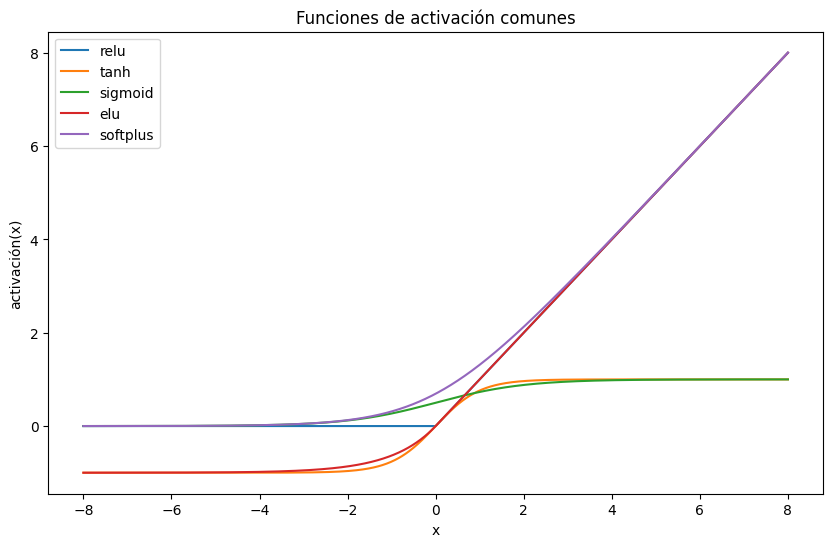

In [2]:
x = np.linspace(-8, 8, 1000)

activaciones = {
    'relu': keras.activations.relu(x),
    'tanh': keras.activations.tanh(x),
    'sigmoid': keras.activations.sigmoid(x),
    'elu': keras.activations.elu(x),
    'softplus': keras.activations.softplus(x)
}

plt.figure(figsize=(10, 6))
for nombre, y in activaciones.items():
    plt.plot(x, y, label=nombre)

plt.title('Funciones de activación comunes')
plt.xlabel('x')
plt.ylabel('activación(x)')
plt.legend()
plt.show()

## Parte 1: Clasificación binaria con make_moons

Construimos un problema no lineal con `make_moons` y entrenamos una red secuencial para separar las dos clases.

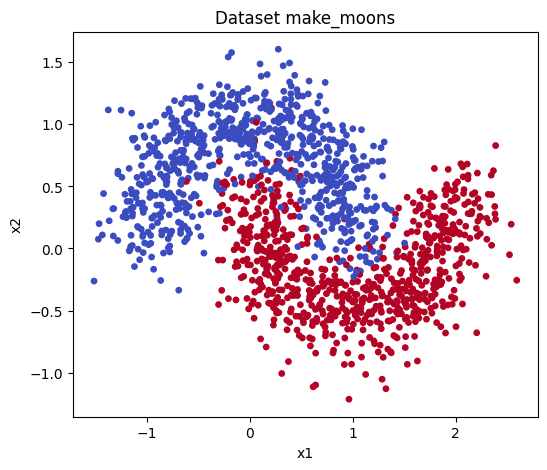

In [3]:
X_moons, y_moons = make_moons(n_samples=1500, noise=0.22, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', s=15)
plt.title('Dataset make_moons')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moons, y_moons, test_size=0.25, random_state=42, stratify=y_moons
)

scaler_m = StandardScaler()
X_train_m = scaler_m.fit_transform(X_train_m)
X_test_m = scaler_m.transform(X_test_m)

In [4]:
modelo_moons = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

modelo_moons.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_moons = modelo_moons.fit(
    X_train_m, y_train_m,
    validation_split=0.2,
    epochs=120,
    batch_size=32,
    verbose=0
)

Accuracy test (moons): 0.9573


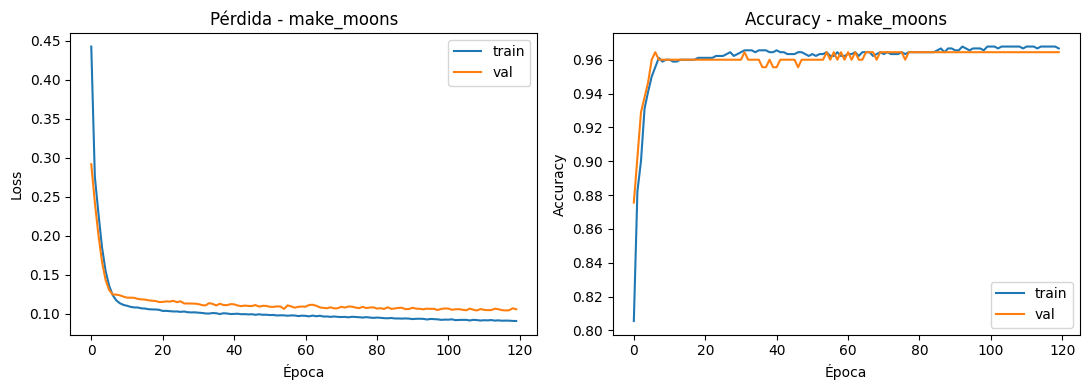

In [5]:
loss_m, acc_m = modelo_moons.evaluate(X_test_m, y_test_m, verbose=0)
print(f'Accuracy test (moons): {acc_m:.4f}')

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.plot(history_moons.history['loss'], label='train')
plt.plot(history_moons.history['val_loss'], label='val')
plt.title('Pérdida - make_moons')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_moons.history['accuracy'], label='train')
plt.plot(history_moons.history['val_accuracy'], label='val')
plt.title('Accuracy - make_moons')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

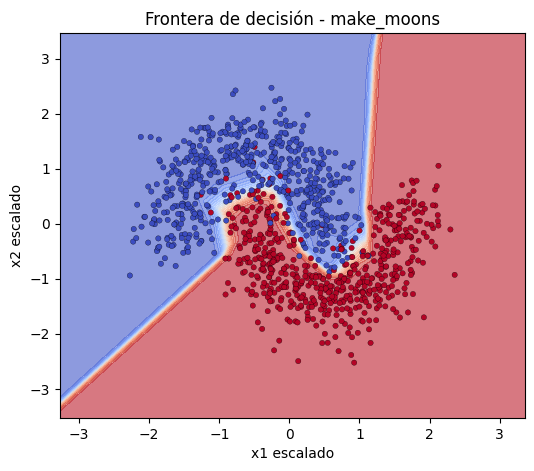

In [6]:
# Frontera de decisión
x_min, x_max = X_train_m[:, 0].min() - 1, X_train_m[:, 0].max() + 1
y_min, y_max = X_train_m[:, 1].min() - 1, X_train_m[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))

grid = np.c_[xx.ravel(), yy.ravel()]
proba = modelo_moons.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, proba, levels=20, cmap='coolwarm', alpha=0.6)
plt.scatter(X_train_m[:, 0], X_train_m[:, 1], c=y_train_m, cmap='coolwarm', s=15, edgecolors='k', linewidth=0.2)
plt.title('Frontera de decisión - make_moons')
plt.xlabel('x1 escalado')
plt.ylabel('x2 escalado')
plt.show()

## Parte 2: Clasificación multiclase con load_digits

Ahora usamos `load_digits`, donde cada imagen de 8x8 píxeles pertenece a una de 10 clases.

X shape: (1797, 64)
Número de clases: 10


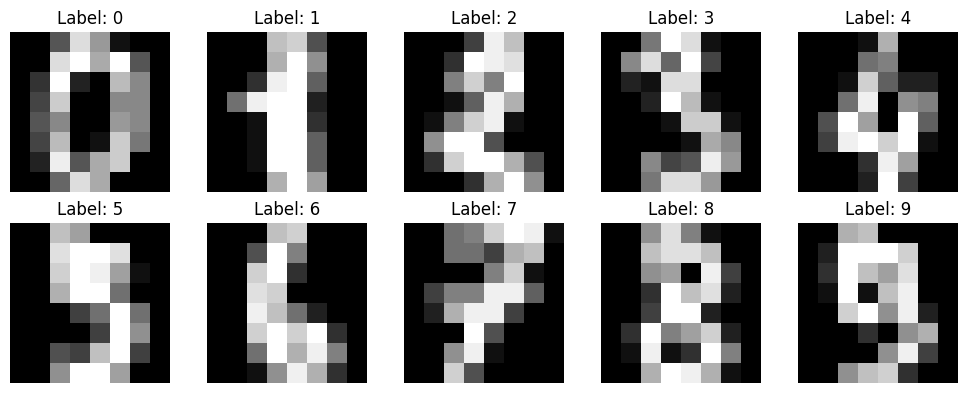

In [7]:
digits = load_digits()
X_d = digits.data
y_d = digits.target

print('X shape:', X_d.shape)
print('Número de clases:', len(np.unique(y_d)))

fig, axs = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axs.ravel()):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {y_d[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42, stratify=y_d
)

scaler_d = StandardScaler()
X_train_d = scaler_d.fit_transform(X_train_d)
X_test_d = scaler_d.transform(X_test_d)

modelo_digits = keras.Sequential([
    keras.layers.Input(shape=(64,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

modelo_digits.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_digits = modelo_digits.fit(
    X_train_d, y_train_d,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    verbose=0
)

Accuracy test (digits): 0.9750
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.97      0.95        36
           2       0.97      0.97      0.97        35
           3       0.97      1.00      0.99        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.95      1.00      0.97        36
           8       0.97      0.89      0.93        35
           9       0.97      0.94      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360



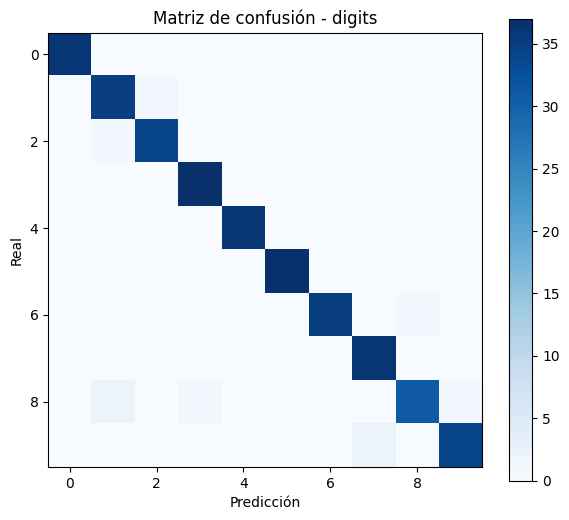

In [9]:
loss_d, acc_d = modelo_digits.evaluate(X_test_d, y_test_d, verbose=0)
print(f'Accuracy test (digits): {acc_d:.4f}')

y_pred_proba = modelo_digits.predict(X_test_d, verbose=0)
y_pred_d = np.argmax(y_pred_proba, axis=1)

print(classification_report(y_test_d, y_pred_d))

cm = confusion_matrix(y_test_d, y_pred_d)
plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='Blues')
plt.title('Matriz de confusión - digits')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.colorbar()
plt.show()

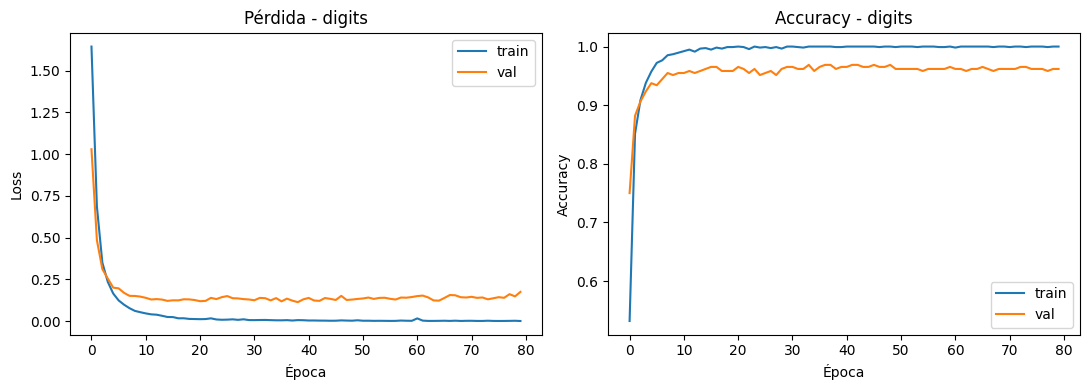

In [10]:
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.plot(history_digits.history['loss'], label='train')
plt.plot(history_digits.history['val_loss'], label='val')
plt.title('Pérdida - digits')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_digits.history['accuracy'], label='train')
plt.plot(history_digits.history['val_accuracy'], label='val')
plt.title('Accuracy - digits')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Conclusiones

1. En clasificación binaria (make_moons), una salida sigmoide y pérdida binaria son una combinación natural.
2. En clasificación multiclase (digits), softmax con `sparse_categorical_crossentropy` permite modelar probabilidades de 10 clases.
3. Las capas ReLU en la parte oculta ayudan a modelar fronteras no lineales de forma eficiente.
4. La validación durante el entrenamiento permite observar si el modelo generaliza o sobreajusta.